In [3]:
import pandas as pd
import numpy as np
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns

print("Environment working!")
print("scikit-learn:", sklearn.__version__)

Environment working!
scikit-learn: 1.9.0


In [4]:
df = pd.read_excel('../data/default+of+credit+card+clients/default of credit card clients.xls', engine='xlrd', index_col=0, header=1 )


In [ ]:
print(df.head())

In [18]:
print(df.shape)

(30000, 24)


In [ ]:
print(df.columns)
print(f"Length of the column: {len(df.columns)}")


In [ ]:
print(df.isna().sum())

In [ ]:
print(df.describe().T)

In [15]:
print(df['default payment next month'].value_counts())

default payment next month
0    23364
1     6636
Name: count, dtype: int64


In [ ]:
print(df['SEX'].value_counts())
print(df['SEX'].value_counts(normalize=True))

In [35]:
print(df["EDUCATION"].value_counts())
print(df["EDUCATION"].value_counts(normalize=True)*100)

EDUCATION
2    14030
1    10585
3     4917
5      280
4      123
6       51
0       14
Name: count, dtype: int64
EDUCATION
2    46.766667
1    35.283333
3    16.390000
5     0.933333
4     0.410000
6     0.170000
0     0.046667
Name: proportion, dtype: float64


In [ ]:
print(df["MARRIAGE"].value_counts())
print(df["MARRIAGE"].value_counts(normalize=True)*100)

In [28]:
def_rate_by_edu= df.groupby("EDUCATION")['default payment next month'].mean().sort_values(ascending=False) * 100
print(def_rate_by_edu)

EDUCATION
3    25.157616
2    23.734854
1    19.234766
6    15.686275
5     6.428571
4     5.691057
0     0.000000
Name: default payment next month, dtype: float64


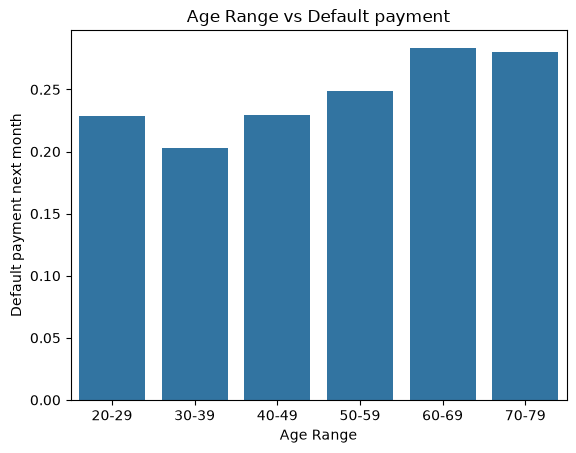

In [43]:
bins= [20, 30, 40, 50 , 60, 70 ,80]
labels= ['20-29', '30-39', '40-49', '50-59', '60-69', '70-79']
df['age_range']= pd.cut(df["AGE"], bins=bins, labels=labels, right=False )


def_rate_by_age= df.groupby('age_range')['default payment next month'].mean().sort_values(ascending=False) * 100
#print(def_rate_by_age)

sns.barplot(data=df, 
            x='age_range',
            y='default payment next month' ,
            order=labels,
            errorbar=None )

plt.xlabel("Age Range")
plt.ylabel("Default payment next month")
plt.title("Age Range vs Default payment")

plt.show()

In [ ]:
def_rate_by_pay0= df.groupby('PAY_0')['default payment next month'].mean().sort_values(ascending=False)*100
print(def_rate_by_pay0)

PAY_0
 7    77.777778
 3    75.776398
 2    69.141357
 4    68.421053
 8    57.894737
 6    54.545455
 5    50.000000
 1    33.947939
-1    16.778051
-2    13.229431
 0    12.811291
Name: default payment next month, dtype: float64


In [2]:
sns.barplot(data=df,
            x="PAY_0", 
            y="default payment next month", 
            order=sorted(df['PAY_0']),
            errorbar=None )

plt.xlabel('PAY_0')
plt.ylabel('Default Rate (%)')
plt.title('Default Rate by PAY_0 Category')

plt.show()

NameError: name 'sns' is not defined

In [ ]:
sns.countplot(data=df, x='default payment next month')
plt.xlabel("Default payment next month")
plt.ylabel("Number of customers")
plt.title('Count of Customers by Default Status')
plt.show()

In [ ]:
from matplotlib.ticker import FuncFormatter
sns.boxplot(
    data=df,
    x="default payment next month",
    y="LIMIT_BAL"
)
plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda value, position: f"{value / 1000:.0f}K")
)
plt.xlabel("Default")
plt.ylabel("Credit Limit")
plt.title("Credit Limit by Default Status")
plt.show()

In [ ]:
from matplotlib.ticker import FuncFormatter
sns.histplot(
    data=df,
    x="LIMIT_BAL",
    hue="default payment next month",
    bins=30,
    kde=True
)
plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda value, position: f"{value / 1000:.0f}K")
)
plt.xlabel("Credit Limit")
plt.title("Credit Limit Distribution by Default Status")
plt.show()

In [ ]:
sns.boxplot(
    data=df,
    x="default payment next month",
    y="BILL_AMT1"
)
plt.ticklabel_format(style='plain', axis='y')
plt.xlabel("Default")
plt.ylabel("Bill Amount")
plt.title("Bill Amount by Default Status")
plt.show()

In [ ]:
sns.boxplot(
    data=df,
    x="default payment next month",
    y="PAY_AMT1"
)

plt.xlabel("Default")
plt.ylabel("Payment Amount")
plt.title("Payment Amount by Default Status")
plt.show()

************************************************************************
--------------------------Correlation Analysis-------------------------
************************************************************************

In [16]:
corr= df.corr(numeric_only=True)
corr['default payment next month'].sort_values(ascending=False) * 100



default payment next month    100.000000
PAY_0                          32.479373
PAY_2                          26.355120
PAY_3                          23.525251
PAY_4                          21.661364
PAY_5                          20.414891
PAY_6                          18.686636
EDUCATION                       2.800608
AGE                             1.388983
BILL_AMT6                      -0.537231
BILL_AMT5                      -0.676046
BILL_AMT4                      -1.015650
BILL_AMT3                      -1.407552
BILL_AMT2                      -1.419322
BILL_AMT1                      -1.964420
MARRIAGE                       -2.433922
SEX                            -3.996058
PAY_AMT6                       -5.318334
PAY_AMT5                       -5.512352
PAY_AMT3                       -5.625035
PAY_AMT4                       -5.682740
PAY_AMT2                       -5.857871
PAY_AMT1                       -7.292949
LIMIT_BAL                     -15.351988
Name: default pa

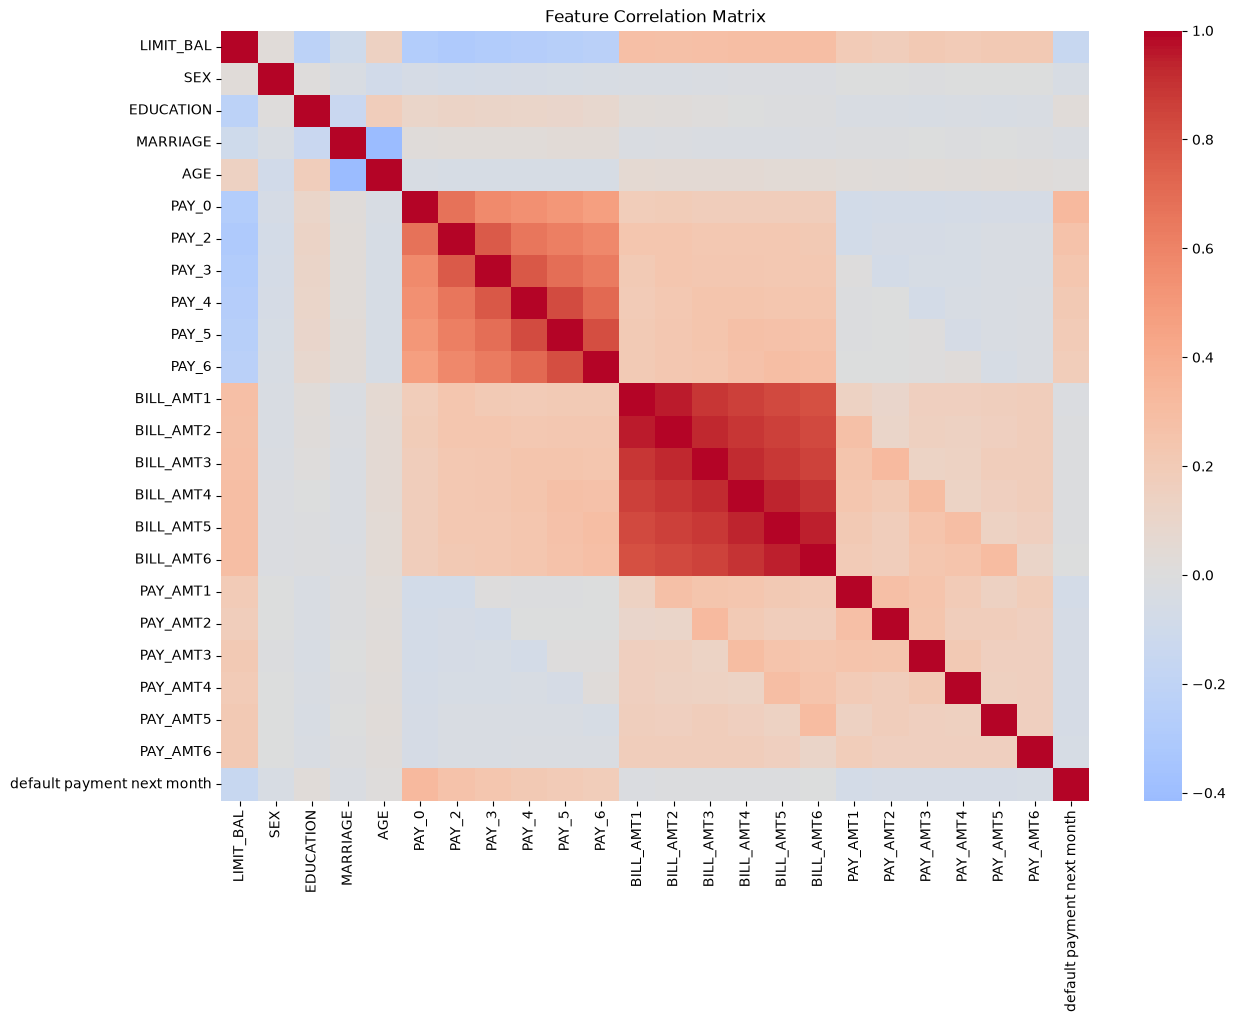

In [17]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Matrix")
plt.show()

************************************************************************
--------------------------Data Preparation-------------------------
************************************************************************

In [7]:
#Choosing Feautures

X= df.drop(columns="default payment next month")
y= df['default payment next month']

#X.shape
#y.shape
#X.head()
#y.head()

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test= train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train.shape
X_test.shape
y_train.shape
y_test.shape

y_train.value_counts(normalize=True)
y_test.value_counts(normalize=True)

default payment next month
0    0.778833
1    0.221167
Name: proportion, dtype: float64

In [13]:
#Defining Feauture groups

categorical_features = [
    "SEX",
    "EDUCATION",
    "MARRIAGE",
    "PAY_0",
    "PAY_2",
    "PAY_3",
    "PAY_4",
    "PAY_5",
    "PAY_6"
]

numerical_features = [
    "LIMIT_BAL",
    "AGE",
    "BILL_AMT1",
    "BILL_AMT2",
    "BILL_AMT3",
    "BILL_AMT4",
    "BILL_AMT5",
    "BILL_AMT6",
    "PAY_AMT1",
    "PAY_AMT2",
    "PAY_AMT3",
    "PAY_AMT4",
    "PAY_AMT5",
    "PAY_AMT6"
]

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

model= LogisticRegression(max_iter=1000)

model.fit(X_train,y_train)

y_pred= model.predict(X_test)

accuracy= accuracy_score(y_test,y_pred)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.8080


c:\Users\Admin\Desktop\project\AI-ML\credit_card_default_predictor\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [41]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))

Accuracy: 0.808
Precision: 0.6842105263157895
Recall: 0.2449133383571967
F1: 0.3607103218645949


In [14]:
#Preprocessing Data

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

preprocessor= ColumnTransformer(
    transformers= [("num", StandardScaler(), numerical_features),
                  ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)]
)

pipeline= Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

pipeline.fit(X_train, y_train)

y_pred= pipeline.predict(X_test)

In [36]:
baseline_pred = [0] * len(y_test)

baseline_accuracy = accuracy_score(y_test, baseline_pred)

print(f"Dummy Baseline Accuracy: {baseline_accuracy:.4f}")

Dummy Baseline Accuracy: 0.7788


In [35]:
from sklearn.metrics import confusion_matrix

con_matrix= confusion_matrix(y_test, y_pred)
print(con_matrix)

[[4523  150]
 [1002  325]]


In [15]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))

from sklearn.metrics import confusion_matrix

con_matrix= confusion_matrix(y_test, y_pred)
print(con_matrix)

Accuracy: 0.8168333333333333
Precision: 0.6614730878186968
Recall: 0.3519216277317257
F1: 0.45941957697983277
[[4434  239]
 [ 860  467]]


************************************************************************
--------------------Model Comparision-------------------------
************************************************************************

In [16]:
from sklearn.tree import DecisionTreeClassifier

tree_model= Pipeline(
    [
        ("preprocessor", preprocessor),
        ("classifier", DecisionTreeClassifier(random_state=42))
    ]
)

tree_model.fit(X_train, y_train)
tree_pred= tree_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, tree_pred))
print("Precision:", precision_score(y_test, tree_pred))
print("Recall:", recall_score(y_test, tree_pred))
print("F1:", f1_score(y_test, tree_pred))

Accuracy: 0.7215
Precision: 0.3778409090909091
Recall: 0.400904295403165
F1: 0.38903107861060326


In [17]:
#Detect Overfitting

tree_train_pred = tree_model.predict(X_train)

print(
    "Training accuracy:",
    accuracy_score(y_train, tree_train_pred)
)

print(
    "Test accuracy:",
    accuracy_score(y_test, tree_pred)
)

Training accuracy: 0.9994583333333333
Test accuracy: 0.7215


In [19]:
#checking out tree depth

tree_model.named_steps["classifier"].get_depth()
tree_model.named_steps["classifier"].get_n_leaves()

np.int64(3797)

In [27]:
#Controlling the tree's complexity

depths = [3, 5, 8, 10, 15,20,30]

for depth in depths:
    tree_model = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", DecisionTreeClassifier(
            max_depth=depth,
            random_state=42
        ))
    ])

    tree_model.fit(X_train, y_train)

    train_pred = tree_model.predict(X_train)
    test_pred = tree_model.predict(X_test)

    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)

    

    tree_pred = tree_model.predict(X_test)

    
    print(
        f"Depth: {depth:2} | "
        f"Train: {train_acc:.4f} | "
        f"Test: {test_acc:.4f}"
    )

   
    print("Accuracy:", accuracy_score(y_test, tree_pred))
    print("Precision:", precision_score(y_test, tree_pred))
    print("Recall:", recall_score(y_test, tree_pred))
    print("F1:", f1_score(y_test, tree_pred))
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, tree_pred))
    print("----------------------------------")


Depth:  3 | Train: 0.8195 | Test: 0.8162
Accuracy: 0.8161666666666667
Precision: 0.6944444444444444
Recall: 0.30143180105501133
F1: 0.42038885969521805

Confusion Matrix:
[[4497  176]
 [ 927  400]]
----------------------------------
Depth:  5 | Train: 0.8241 | Test: 0.8153
Accuracy: 0.8153333333333334
Precision: 0.6746411483253588
Recall: 0.31876412961567446
F1: 0.4329580348004094

Confusion Matrix:
[[4469  204]
 [ 904  423]]
----------------------------------
Depth:  8 | Train: 0.8358 | Test: 0.8117
Accuracy: 0.8116666666666666
Precision: 0.644640234948605
Recall: 0.3308214016578749
F1: 0.43725099601593626

Confusion Matrix:
[[4431  242]
 [ 888  439]]
----------------------------------
Depth: 10 | Train: 0.8491 | Test: 0.8075
Accuracy: 0.8075
Precision: 0.6264705882352941
Recall: 0.32102486812358705
F1: 0.42451420029895365

Confusion Matrix:
[[4419  254]
 [ 901  426]]
----------------------------------
Depth: 15 | Train: 0.8932 | Test: 0.7875
Accuracy: 0.7875
Precision: 0.530303030303

Even at its best decision tree couldnt beat logistic regression

                    Logistic    Tree depth 8
Accuracy              81.68%        81.17%
Precision             66.15%        64.46%
Recall                35.19%        33.08%
F1                    45.94%        43.73%

Phase 5 — Random Forest
Objective

Use an ensemble of decision trees to obtain a more robust model and see whether combining many trees improves our predictions.

Concepts 

- Ensemble learning
- Random Forest
- Bootstrap sampling
- Feature randomness
- Bias/variance
- Overfitting reduction

In [28]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

In [29]:
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall:", recall_score(y_test, rf_pred))
print("F1:", f1_score(y_test, rf_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

Accuracy: 0.8143333333333334
Precision: 0.6441136671177267
Recall: 0.35870384325546345
F1: 0.46079380445304935

Confusion Matrix:
[[4410  263]
 [ 851  476]]


Phase 5.2 — Probability and Decision Thresholds
Objective

Understand how a classification model converts probabilities into class predictions and how changing the threshold affects precision and recall.

Concepts
- predict_proba()
- Classification threshold
- Precision–recall tradeoff
- Business decision-making

In [37]:
rf_default_prob = rf_model.predict_proba(X_test)[:,1]

print(rf_default_prob [:10])

[0.08 0.28 0.14 0.15 0.03 0.41 0.15 0.   0.1  0.1 ]


In [38]:
threshold = 0.30

rf_pred_30 = (rf_default_prob >= threshold).astype(int)

print("Accuracy:", accuracy_score(y_test, rf_pred_30))
print("Precision:", precision_score(y_test, rf_pred_30))
print("Recall:", recall_score(y_test, rf_pred_30))
print("F1:", f1_score(y_test, rf_pred_30))

Accuracy: 0.7753333333333333
Precision: 0.49291975724882
Recall: 0.5508666164280331
F1: 0.5202846975088968


Phase 5.3 — Find the Best Threshold
Objective

Instead of arbitrarily choosing 0.30, investigate how model performance changes across many thresholds and choose a threshold based on an explicit criterion.

Concepts
- Threshold tuning
- Precision–recall tradeoff
- F1 optimization
- Model evaluation

In [39]:

thresholds = np.arange(0.10, 0.91, 0.05)

for threshold in thresholds:
    predictions = (rf_default_prob >= threshold).astype(int)

    precision = precision_score(y_test, predictions)
    recall = recall_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)

    print(
        f"Threshold: {threshold:.2f} | "
        f"Precision: {precision:.3f} | "
        f"Recall: {recall:.3f} | "
        f"F1: {f1:.3f}"
    )

Threshold: 0.10 | Precision: 0.273 | Recall: 0.898 | F1: 0.419
Threshold: 0.15 | Precision: 0.324 | Recall: 0.763 | F1: 0.455
Threshold: 0.20 | Precision: 0.385 | Recall: 0.671 | F1: 0.489
Threshold: 0.25 | Precision: 0.446 | Recall: 0.595 | F1: 0.510
Threshold: 0.30 | Precision: 0.501 | Recall: 0.542 | F1: 0.521
Threshold: 0.35 | Precision: 0.547 | Recall: 0.497 | F1: 0.521
Threshold: 0.40 | Precision: 0.587 | Recall: 0.457 | F1: 0.514
Threshold: 0.45 | Precision: 0.617 | Recall: 0.411 | F1: 0.493
Threshold: 0.50 | Precision: 0.644 | Recall: 0.359 | F1: 0.461
Threshold: 0.55 | Precision: 0.673 | Recall: 0.311 | F1: 0.426
Threshold: 0.60 | Precision: 0.694 | Recall: 0.267 | F1: 0.385
Threshold: 0.65 | Precision: 0.711 | Recall: 0.209 | F1: 0.324
Threshold: 0.70 | Precision: 0.718 | Recall: 0.151 | F1: 0.250
Threshold: 0.75 | Precision: 0.780 | Recall: 0.107 | F1: 0.188
Threshold: 0.80 | Precision: 0.798 | Recall: 0.063 | F1: 0.116
Threshold: 0.85 | Precision: 0.849 | Recall: 0.034 | F1

Phase 6 — Cross-Validation & Hyperparameter Tuning
Objective

Find a model configuration that generalizes well without making decisions based on our test set.

Concepts
- Cross-validation
- Validation data
- Hyperparameter tuning
- GridSearchCV
- Generalization
- Data leakage

The basic idea is:

                  Training data
                       │
             ┌─────────┴─────────┐
             ↓                   ↓
        Cross-validation     Final test set
             │                   │
       model selection        untouched
             │                   │
             ↓                   │
       Final model ──────────────┘
                       ↓
                 Final evaluation

Instead of relying on one split, cross-validation repeatedly divides the training data.

In [40]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [41]:
param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [5, 10, None],
    "classifier__min_samples_leaf": [1, 5, 10]
}

In [42]:
from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=cv,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

In [44]:
grid_search.fit(X_train, y_train)

print("Best parameters:")
print(grid_search.best_params_)

print("\nBest cross-validation F1:")
print(grid_search.best_score_)

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best parameters:
{'classifier__max_depth': None, 'classifier__min_samples_leaf': 1, 'classifier__n_estimators': 200}

Best cross-validation F1:
0.4738809625706327


Phase 6.2 — Final Test Evaluation of the Tuned Model
Objective

Evaluate the model selected through cross-validation on completely unseen data.

This is the first point where we're going to treat the test set as the final examination.

In [45]:
#Final Test Evaluation of the Tuned Model
best_model = grid_search.best_estimator_

best_pred = best_model.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, best_pred))
print("Test Precision:", precision_score(y_test, best_pred))
print("Test Recall:", recall_score(y_test, best_pred))
print("Test F1:", f1_score(y_test, best_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, best_pred))

Test Accuracy: 0.8165
Test Precision: 0.6502659574468085
Test Recall: 0.36850037678975134
Test F1: 0.4704184704184704

Confusion Matrix:
[[4410  263]
 [ 838  489]]


Phase 6.3 — Validation Set for Threshold Selection
Objective

Choose the classification threshold without touching the final test set.

Concepts
- Training / validation / test sets
- Threshold tuning
- Data leakage
- Nested decision-making

Currently we have:

Training → model fitting + cross-validation
Test     → final evaluation

We need somewhere to experiment with thresholds.

We could create:

Training 
   ↓

Train + Validation


Test
   ↓
Final evaluation

For simplicity, we'll make a validation split from our existing training data.

In [47]:
from sklearn.model_selection import train_test_split

X_train_model, X_val, y_train_model, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=42
)

In [48]:
final_selection_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        min_samples_leaf=1,
        random_state=42,
        n_jobs=-1
    ))
])

final_selection_model.fit(X_train_model, y_train_model)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](23,)","['LIMIT_BAL','SEX','EDUCATION',...,'PAY_AMT4','PAY_AMT5','PAY_AMT6']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,23
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, al

In [53]:
val_prob = final_selection_model.predict_proba(X_val)[:, 1]

In [ ]:
thresholds = np.arange(0.10, 0.91, 0.05)

for threshold in thresholds:
    val_pred = (val_prob >= threshold).astype(int)

    precision = precision_score(y_val, val_pred)
    recall = recall_score(y_val, val_pred)
    f1 = f1_score(y_val, val_pred)

    print(
        f"Threshold: {threshold:.2f} | "
        f"Precision: {precision:.3f} | "
        f"Recall: {recall:.3f} | "
        f"F1: {f1:.3f}"
    )

Threshold: 0.10 | Precision: 0.280 | Recall: 0.917 | F1: 0.429
Threshold: 0.15 | Precision: 0.340 | Recall: 0.807 | F1: 0.479
Threshold: 0.20 | Precision: 0.404 | Recall: 0.696 | F1: 0.512
Threshold: 0.25 | Precision: 0.465 | Recall: 0.608 | F1: 0.527
Threshold: 0.30 | Precision: 0.516 | Recall: 0.551 | F1: 0.533
Threshold: 0.35 | Precision: 0.562 | Recall: 0.508 | F1: 0.534
Threshold: 0.40 | Precision: 0.594 | Recall: 0.459 | F1: 0.518
Threshold: 0.45 | Precision: 0.628 | Recall: 0.426 | F1: 0.507
Threshold: 0.50 | Precision: 0.655 | Recall: 0.381 | F1: 0.482
Threshold: 0.55 | Precision: 0.671 | Recall: 0.328 | F1: 0.440
Threshold: 0.60 | Precision: 0.707 | Recall: 0.278 | F1: 0.399
Threshold: 0.65 | Precision: 0.738 | Recall: 0.218 | F1: 0.336
Threshold: 0.70 | Precision: 0.745 | Recall: 0.152 | F1: 0.252
Threshold: 0.75 | Precision: 0.721 | Recall: 0.088 | F1: 0.156
Threshold: 0.80 | Precision: 0.774 | Recall: 0.045 | F1: 0.085
Threshold: 0.85 | Precision: 0.632 | Recall: 0.011 | F1

Phase 6.4 — Final Model Evaluation

Objective

Evaluate our complete modeling pipeline on data that has never been used for model selection or threshold selection.

In [54]:
test_prob = final_selection_model.predict_proba(X_test)[:, 1]

In [55]:
final_threshold = 0.35

final_pred = (test_prob >= final_threshold).astype(int)

In [56]:
print("Final Accuracy:", accuracy_score(y_test, final_pred))
print("Final Precision:", precision_score(y_test, final_pred))
print("Final Recall:", recall_score(y_test, final_pred))
print("Final F1:", f1_score(y_test, final_pred))

print("\nFinal Confusion Matrix:")
print(confusion_matrix(y_test, final_pred))

Final Accuracy: 0.8001666666666667
Final Precision: 0.5516962843295639
Final Recall: 0.5146948003014318
Final F1: 0.5325536062378168

Final Confusion Matrix:
[[4118  555]
 [ 644  683]]
